<a href="https://colab.research.google.com/github/ghofrane-najjar/tarek-maatoug/blob/main/TP_ASTAR_Localite_Memoire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import random
import math
import heapq
import time
import gc
import matplotlib.pyplot as plt

**PARTIE** 1 — Génération du graphe

In [48]:
def generate_grid(N):
    graph = {}

    for i in range(N):
        for j in range(N):
            neighbors = []

            for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
                ni, nj = i + di, j + dj

                if 0 <= ni < N and 0 <= nj < N:
                    weight = random.randint(1,10)
                    neighbors.append(((ni,nj), weight))

            graph[(i,j)] = neighbors

    return graph

In [49]:
N = 10
graph = generate_grid(N)

**PARTIE 2 —** Matrice d’adjacence

In [50]:
def to_matrix(graph, N):
    size = N * N
    M = [[float('inf')] * size for _ in range(size)]

    def idx(i, j):
        return i * N + j

    for (u_i, u_j), neighbors in graph.items():
        u = idx(u_i, u_j)

        for (v_i, v_j), w in neighbors:
            v = idx(v_i, v_j)
            M[u][v] = w

    return M

In [51]:
N = 5
graph = generate_grid(N)

M = to_matrix(graph, N)

print(M[0])  # afficher les voisins du premier nœud

[inf, 6, inf, inf, inf, 4, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf]


**PARTIE 3 **— CSR

In [52]:
def to_csr(graph, N):
    indptr = [0]
    indices = []
    weights = []

    nodes = [(i, j) for i in range(N) for j in range(N)]

    for u in nodes:
        for v, w in graph[u]:
            indices.append(v[0] * N + v[1])
            weights.append(w)

        indptr.append(len(indices))

    return indptr, indices, weights

**PARTIE 4 **— Algorithme A*

Heuristique

In [53]:
def heuristic(a, b):
    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

A* LISTE

In [54]:
def a_star_list(graph, start, goal):
    open_set = [(0, start)]
    heapq.heapify(open_set)

    g = {start: 0}

    while open_set:
        _, current = heapq.heappop(open_set)

        if current == goal:
            return g[current]

        for neighbor, w in graph[current]:
            tentative = g[current] + w

            if neighbor not in g or tentative < g[neighbor]:
                g[neighbor] = tentative
                heapq.heappush(open_set, (tentative + heuristic(neighbor, goal), neighbor))

    return float('inf')

A* MATRICE

In [55]:
def a_star_matrix(M, N, start, goal):
    def idx(i, j):
        return i * N + j

    open_set = [(0, start)]
    heapq.heapify(open_set)

    g = {start: 0}

    while open_set:
        _, current = heapq.heappop(open_set)

        if current == goal:
            return g[current]

        ci, cj = current

        for ni in range(N):
            for nj in range(N):
                w = M[idx(ci,cj)][idx(ni,nj)]

                if w != float('inf'):
                    neighbor = (ni,nj)
                    tentative = g[current] + w

                    if neighbor not in g or tentative < g[neighbor]:
                        g[neighbor] = tentative
                        heapq.heappush(open_set, (tentative + heuristic(neighbor, goal), neighbor))

    return float('inf')

A* CSR

In [56]:
def a_star_csr(indptr, indices, weights, N, start, goal):

    def idx(i, j):
        return i * N + j

    open_set = [(0, start)]
    heapq.heapify(open_set)

    g = {start: 0}

    while open_set:
        _, current = heapq.heappop(open_set)

        if current == goal:
            return g[current]

        u = idx(*current)

        for k in range(indptr[u], indptr[u+1]):
            v = indices[k]
            w = weights[k]

            neighbor = (v // N, v % N)

            tentative = g[current] + w

            if neighbor not in g or tentative < g[neighbor]:
                g[neighbor] = tentative
                heapq.heappush(
                    open_set,
                    (tentative + heuristic(neighbor, goal), neighbor)
                )

    return float('inf')

**PARTIE 5 —** Benchmark (mesure performance)

In [57]:
def measure(func, *args):
    gc.collect()
    gc.disable()

    start = time.perf_counter()
    result = func(*args)
    end = time.perf_counter()

    gc.enable()

    return end - start, result

**PARTIE 6** — Graphiques

In [58]:
Ns = [10, 20, 30, 40]

t_list = []
t_mat = []
t_csr = []

for N in Ns:
    graph = generate_grid(N)
    start = (0,0)
    goal = (N-1,N-1)

    M = to_matrix(graph, N)
    csr = to_csr(graph, N)

    t, _ = measure(a_star_list, graph, start, goal)
    t_list.append(t)

    t, _ = measure(a_star_matrix, M, N, start, goal)
    t_mat.append(t)

    t, _ = measure(a_star_csr, *csr, N, start, goal)
    t_csr.append(t)

**Graphique final**

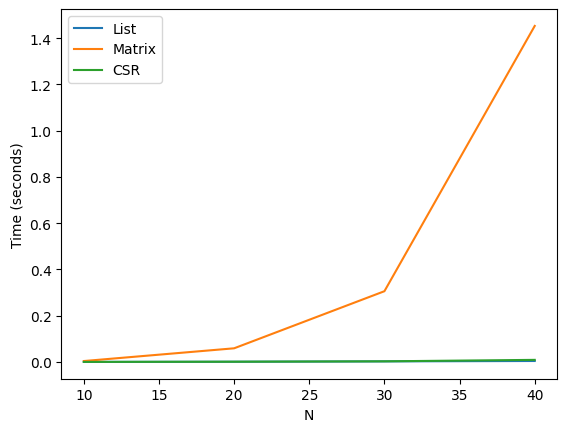

In [59]:
plt.plot(Ns, t_list, label="List")
plt.plot(Ns, t_mat, label="Matrix")
plt.plot(Ns, t_csr, label="CSR")

plt.xlabel("N")
plt.ylabel("Time (seconds)")
plt.legend()
plt.show()